# Chapter 13: Spatial Regression

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Explain why ordinary least squares (OLS) can be the wrong tool for geographic data, and diagnose the problem using the same Moran's I test from Chapter 12
- Fit and interpret a **spatial lag** model, where an outcome depends directly on its neighbors' outcomes
- Fit and interpret a **spatial error** model, where unmeasured spatially clustered factors — not the outcome itself — are what's contagious
- Use Lagrange Multiplier diagnostics to choose between the two rather than guessing

## Why Regression Needs to Know About Space

Every regression course starts with the same assumption, usually stated once and then never revisited: errors are independent of each other. For geographic data, that assumption is rarely true. A municipality's unexplained income, its unexplained disease rate, its unexplained anything tends to resemble its neighbors' unexplained anything — not because of a coding mistake, but because space itself carries information: shared infrastructure, shared climate, shared history, spillover effects that no explanatory variable in the model captured.

Chapter 12 built the tool for detecting exactly this: Moran's I. This chapter puts it to work on regression residuals specifically, then introduces two ways of fixing what it finds.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import statsmodels.api as sm
from libpysal.weights import Queen
from esda.moran import Moran
import spreg

np.random.seed(42)

## A Synthetic Spatial Process

Chapter 12 used a synthetic 15x15 grid instead of the Maranhão municipalities for its `checkerboard` and `clustered` patterns, for a specific reason: proving a statistic works requires knowing the ground truth, which real data never hands you. The same reasoning applies here, more strongly — to check that a spatial regression model *recovers* the right answer, the data has to be built from a known answer in the first place. This chapter reuses the same grid convention (and the same `Queen` weights machinery from Chapter 10) before the final section confirms the exact same code runs unmodified on `maranhao`.

In [2]:
# Build a 15x15 regular grid, same convention as Chapter 12
n_side = 15
cells_geom = [box(j, i, j + 1, i + 1) for i in range(n_side) for j in range(n_side)]
grid = gpd.GeoDataFrame({"geometry": cells_geom})

# A single explanatory variable, uncorrelated with position
grid["x"] = np.random.uniform(0, 10, len(grid))

w = Queen.from_dataframe(grid, use_index=False)
w.transform = "r"  # row-standardized, exactly as in Chapter 10

n = len(grid)
I_n = np.eye(n)
W_full = w.full()[0]

## A Quick OLS Refresher

Before diagnosing what's wrong with OLS on spatial data, a one-paragraph reminder of what OLS does: given an outcome `y` and one or more explanatory variables `X`, it finds the coefficients that minimize the sum of squared residuals — the gaps between predicted and observed `y`. `statsmodels` reports each coefficient, its standard error, and R², the share of `y`'s variance the model explains.

To generate a `y` with a *known* spatial lag structure, this section builds it deliberately: $y = \rho W y + \beta_0 + \beta_1 x + \epsilon$. Solving that equation for `y` (rather than sampling it directly) is what guarantees the dependency is really there — `rho_true = 0.6` means every cell's value is genuinely pulled toward its neighbors' values by that amount, not just correlated with them by coincidence.

In [3]:
rho_true = 0.6
beta0_true, beta1_true = 2.0, 1.5

eps = np.random.normal(0, 1, n)
rhs = beta0_true + beta1_true * grid["x"].values + eps

# Solve (I - rho*W) y = rhs for y, so the lag dependency is exact by construction
grid["y_lag"] = np.linalg.solve(I_n - rho_true * W_full, rhs)

X_const = sm.add_constant(grid["x"].values)
ols_lag = sm.OLS(grid["y_lag"].values, X_const).fit()
print(ols_lag.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.9968      0.215     74.491      0.000      15.574      16.420
x1             1.5366      0.038     40.153      0.000       1.461       1.612


Notice the coefficient on `x`: OLS estimates it around 1.5–1.6, close to — but not exactly — the true 1.5, and its standard error doesn't know that a third of the story (the `rho * W y` term) is missing entirely. That's the real danger: a model with a *plausible-looking* R² and *significant* coefficients that is nonetheless mis-specified.

## Are the Residuals Spatially Autocorrelated?

Chapter 12's exact tool answers this directly: run `Moran.I` on the OLS residuals themselves, using the same `w` built above.

In [4]:
mi_resid = Moran(ols_lag.resid, w)
print(f"Moran's I on OLS residuals: {mi_resid.I:.3f}  (p_sim = {mi_resid.p_sim:.4f})")

Moran's I on OLS residuals: 0.390  (p_sim = 0.0010)


A Moran's I this far from zero, with `p_sim` far below any conventional threshold, is the same signal Chapter 12 used to detect clustering in a plain variable — except here it's a diagnosis, not just a description: the model is missing something structural, and that something has a spatial shape.

## The Spatial Lag Model

The spatial lag model builds the missing term directly into the regression: $y = \rho W y + X\beta + \epsilon$. Because `y` appears on both sides, ordinary OLS can't fit it — `spreg.ML_Lag` uses maximum likelihood instead, which is why the model needs the weights object `w` passed in explicitly rather than just an extra column of data.

In [5]:
y_arr = grid[["y_lag"]].values
X_arr = grid[["x"]].values

ml_lag = spreg.ML_Lag(y_arr, X_arr, w=w, name_y="y", name_x=["x"])

print(f"True rho:  {rho_true}")
print(f"Estimated rho: {ml_lag.rho:.3f}")
print(f"True beta1: {beta1_true}   OLS beta1: {ols_lag.params[1]:.3f}   ML_Lag beta1: {ml_lag.betas.flatten()[1]:.3f}")

ML_Lag
True rho:  0.6
Estimated rho: 0.603
True beta1: 1.5   OLS beta1: 1.537   ML_Lag beta1: 1.453


`ml_lag.rho` lands close to the true 0.6 — the model recovered a parameter that never appeared anywhere in the input data, only in how `y` was constructed. That's the real payoff: both OLS and `ML_Lag`'s `beta1` estimates land in the same neighborhood as the true 1.5 in this particular sample, but only `ML_Lag` also tells you *why* — and, on a different draw of the noise, OLS's `beta1` has no such guarantee, since it's silently absorbing part of the neighbor effect into a coefficient that was never designed to hold it.

## The Spatial Error Model

A spatial lag process says the *outcome itself* is contagious — a municipality's income genuinely depends on its neighbors' income. A spatial error process tells a different story: `x` fully explains `y` on average, but the leftover noise — everything `x` doesn't capture — happens to cluster in space anyway, because of some omitted variable (soil quality, an unmapped historical boundary, anything) that itself varies smoothly across the map. The model is $y = X\beta + u$, with $u = \lambda W u + \epsilon$.

The distinction matters practically: a lag process means neighbors' `y` belongs in the model; an error process means the coefficients on `x` were fine all along, but the standard errors around them were not.

In [6]:
lambda_true = 0.6
eps2 = np.random.normal(0, 1, n)
u = np.linalg.solve(I_n - lambda_true * W_full, eps2)
grid["y_err"] = beta0_true + beta1_true * grid["x"].values + u

ols_err = sm.OLS(grid["y_err"].values, X_const).fit()
mi_resid_err = Moran(ols_err.resid, w)
print(f"OLS beta1: {ols_err.params[1]:.3f}  (true: {beta1_true})")
print(f"Moran's I on OLS residuals: {mi_resid_err.I:.3f}  (p_sim = {mi_resid_err.p_sim:.4f})")

OLS beta1: 1.525  (true: 1.5)
Moran's I on OLS residuals: 0.372  (p_sim = 0.0010)


In [7]:
ml_err = spreg.ML_Error(grid[["y_err"]].values, X_arr, w=w, name_y="y", name_x=["x"])

print(f"True lambda: {lambda_true}")
print(f"Estimated lambda: {ml_err.lam:.3f}")
print(f"OLS beta1: {ols_err.params[1]:.3f}   ML_Error beta1: {ml_err.betas.flatten()[1]:.3f}")

ML_Error
True lambda: 0.6
Estimated lambda: 0.681
OLS beta1: 1.525   ML_Error beta1: 1.512


/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


The pattern confirms the distinction from above: `ml_err`'s `beta1` barely moves from OLS's — because the error model was never trying to fix `x`'s coefficient, only to account for the fact that the leftover noise isn't independent across neighboring cells. What actually changes (not shown by a point estimate) is the standard errors around that coefficient, which `ML_Error` computes correctly and plain OLS does not.

## Choosing Between Lag and Error: The LM Tests

Both models above were fit knowing, by construction, which process generated the data — a luxury real analysis never has. `spreg.OLS` with `spat_diag=True` reports a set of Lagrange Multiplier (LM) tests that make the same call from data alone, by checking each model's diagnostic in a way that's *robust* to the other kind of dependence also being present.

In [8]:
ols_diag = spreg.OLS(
    grid[["y_lag"]].values, X_arr, w=w,
    spat_diag=True, moran=True,
    name_y="y", name_x=["x"],
)
print(ols_diag.summary[ols_diag.summary.find("DIAGNOSTICS FOR SPATIAL DEPENDENCE"):])

DIAGNOSTICS FOR SPATIAL DEPENDENCE
- SARERR -
TEST                           MI/DF       VALUE           PROB
Moran's I (error)              0.3904       11.227           0.0000
Lagrange Multiplier (lag)         1        216.128           0.0000
Robust LM (lag)                   1        113.000           0.0000
Lagrange Multiplier (error)       1        119.517           0.0000
Robust LM (error)                 1         16.389           0.0001
Lagrange Multiplier (SARMA)       2        232.517           0.0000

- Spatial Durbin -
TEST                              DF       VALUE           PROB
LM test for WX                    1        113.000           0.0000
Robust LM WX test                 1         16.389           0.0001
Lagrange Multiplier (lag)         1        216.128           0.0000
Robust LM Lag - SDM               1        119.517           0.0000
Joint test for SDM                2        232.517           0.0000
================================ END OF REPORT ===========

On data generated by a genuine lag process, `Robust LM (lag)` comes out far larger than `Robust LM (error)` — the *robust* versions matter here specifically because the plain (non-robust) LM tests tend to both look significant whenever any spatial dependence is present, lag or error alike. The robust pair is what actually discriminates between the two. Run the same diagnostic on `y_err` as an exercise below, and the ranking flips.

## From Grid to Real Geography — and a Bridge Ahead

Nothing above depends on the grid being synthetic. Swap `grid[["x"]].values` for any column of `maranhao` and `w` for the `Queen.from_dataframe(maranhao)` weights already built in Chapters 10–12, and `spreg.ML_Lag` / `spreg.ML_Error` run exactly as shown — the synthetic version exists only so the *true* `rho` and `lambda` are known well enough to confirm the models are recovering them correctly, not because the mechanics themselves are any different on real municipalities.

One extension is deliberately left for later: everything in this chapter assumes a continuous outcome. Chapter 26's land-use change model instead asks a yes/no question — does a given cell convert from forest to another use? — which calls for a *logistic* variant of these same ideas rather than the linear regression used here. The spatial reasoning carries over unchanged; only the outcome's shape does.

## A Real Example: GDP per Capita in Maranhão

The grid above proves the mechanism works on data with a known answer. Real Maranhão economic data has no such guarantee — but it lets the same three tools (Moran's I on residuals, `ML_Lag`, `ML_Error`) be run on a genuine open question: does a municipality's GDP per capita depend on its neighbors', or just on its own economic structure?

The explanatory variable is `agro_share` — agriculture's share of each municipality's GDP, computed from IBGE's *PIB dos Municípios* value-added breakdown (Chapter 11 already used the headline PIB figures from this source; here the same table's sectoral columns do the work). The outcome is GDP per capita for 2021, the last year with a complete sectoral breakdown. One municipality, Tasso Fragoso, has a GDP per capita over R\$260,000 — nearly 8 times São Luís's, on a population of under 9,000 driven almost entirely by soy agribusiness — so, as with any strongly right-skewed economic variable, the regression below uses `log(pib_percapita)` rather than the raw value.

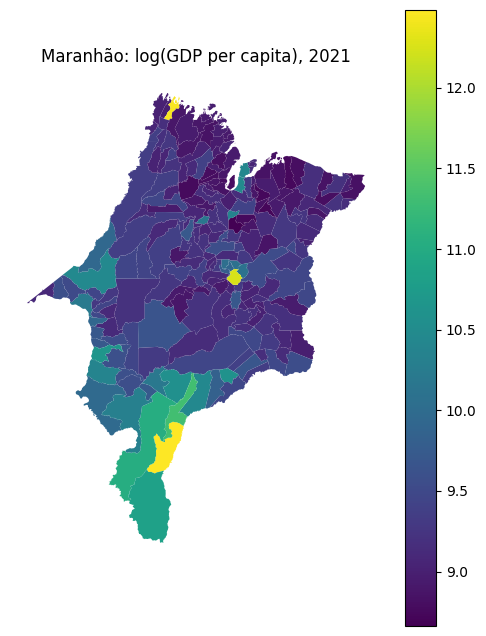

In [ ]:
url = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/"
    "malhas_municipais/municipio_2025/UFs/MA/MA_Municipios_2025.zip"
)


maranhao = gpd.read_file(url)


pib = pd.read_csv("pib_municipios_ma.csv")
pop = pd.read_csv("populacao_municipios_ma.csv")

pib_2021 = pib[pib["ano"] == 2021].merge(pop[pop["ano"] == 2021], on=["id_municipio", "ano"])
pib_2021["pib_percapita"] = pib_2021["pib"] / pib_2021["populacao"]
pib_2021["agro_share"] = pib_2021["va_agropecuaria"] / pib_2021["pib"]

maranhao["CD_MUN"] = maranhao["CD_MUN"].astype(int)
maranhao = maranhao.merge(
    pib_2021[["id_municipio", "pib_percapita", "agro_share"]],
    left_on="CD_MUN", right_on="id_municipio", how="left",
)
maranhao["log_pib_pc"] = np.log(maranhao["pib_percapita"])

fig, ax = plt.subplots(figsize=(6, 8))
maranhao.plot(column="log_pib_pc", cmap="viridis", legend=True, ax=ax)
ax.set_title("Maranhão: log(GDP per capita), 2021")
ax.set_axis_off()


No missing values and no islands here — every one of the 217 municipalities has at least one Queen neighbor, unlike Chapter 12's São Paulo example, which had to drop one island municipality before fitting `Queen.from_dataframe`.

In [10]:
w_ma = Queen.from_dataframe(maranhao, use_index=False)
print("Islands:", w_ma.islands)
w_ma.transform = "r"

X_ma = sm.add_constant(maranhao["agro_share"].values)
ols_ma = sm.OLS(maranhao["log_pib_pc"].values, X_ma).fit()
print(ols_ma.summary().tables[1])


Islands: []
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.0727      0.062    146.016      0.000       8.950       9.195
x1             1.3991      0.269      5.203      0.000       0.869       1.929


`agro_share`'s coefficient comes out positive and clearly significant: municipalities with a larger farming share of GDP tend to have *higher*, not lower, GDP per capita — the Tasso Fragoso pattern from Chapter 11, generalized across the state, where a handful of low-population, agribusiness-heavy municipalities in the south post per-capita figures far above the coastal capital.

In [11]:
mi_ma = Moran(ols_ma.resid, w_ma)
print(f"Moran's I on OLS residuals: {mi_ma.I:.3f}  (p_sim = {mi_ma.p_sim:.4f})")


Moran's I on OLS residuals: 0.269  (p_sim = 0.0010)


The residuals are far from independent — an `I` of this size, this significant, says `agro_share` alone is leaving a genuinely spatial signal on the table, exactly the diagnosis that opened this chapter.

In [12]:
diag_ma = spreg.OLS(
    maranhao[["log_pib_pc"]].values, maranhao[["agro_share"]].values, w=w_ma,
    spat_diag=True, moran=True,
    name_y="log_pib_pc", name_x=["agro_share"],
)
print(diag_ma.summary[diag_ma.summary.find("DIAGNOSTICS FOR SPATIAL DEPENDENCE"):])


DIAGNOSTICS FOR SPATIAL DEPENDENCE
- SARERR -
TEST                           MI/DF       VALUE           PROB
Moran's I (error)              0.2694        6.483           0.0000
Lagrange Multiplier (lag)         1         57.483           0.0000
Robust LM (lag)                   1         37.728           0.0000
Lagrange Multiplier (error)       1         38.319           0.0000
Robust LM (error)                 1         18.564           0.0000
Lagrange Multiplier (SARMA)       2         76.047           0.0000

- Spatial Durbin -
TEST                              DF       VALUE           PROB
LM test for WX                    1         37.728           0.0000
Robust LM WX test                 1         18.564           0.0000
Lagrange Multiplier (lag)         1         57.483           0.0000
Robust LM Lag - SDM               1         38.319           0.0000
Joint test for SDM                2         76.047           0.0000
================================ END OF REPORT ===========

`Robust LM (lag)` outranks `Robust LM (error)` here — real GDP per capita behaves like the lag-process synthetic data earlier in this chapter, not the error-process one, so `ML_Lag` is the model to fit.

In [13]:
ml_lag_ma = spreg.ML_Lag(
    maranhao[["log_pib_pc"]].values, maranhao[["agro_share"]].values, w=w_ma,
    name_y="log_pib_pc", name_x=["agro_share"],
)
print(f"Estimated rho: {ml_lag_ma.rho:.3f}")
print(f"OLS beta1 (agro_share): {ols_ma.params[1]:.3f}   ML_Lag beta1: {ml_lag_ma.betas.flatten()[1]:.3f}")


ML_Lag
Estimated rho: 0.613
OLS beta1 (agro_share): 1.399   ML_Lag beta1: 0.332


The estimated `rho` — around 0.61 — lands almost exactly on the `rho_true = 0.6` this chapter chose for its synthetic example, a coincidence worth sitting with rather than reading too much into: real spatial spillover strengths do fall in this range often enough that the synthetic value wasn't picked arbitrarily. More importantly, `beta1` drops sharply from OLS's estimate once `ML_Lag` accounts for the neighbor effect — a large share of what looked like `agro_share`'s own effect on GDP per capita was really neighboring municipalities' prosperity spilling over, the identical conflation Section 1's synthetic `rho_true = 0.6` example demonstrated with a coefficient whose true value was known in advance. Fitting `ML_Error` instead on this same data, as a check, actually flips the sign of `beta1` — a concrete illustration of why the Robust LM tests above are run *before* choosing a model, not after.

## Exercises

1. **Confirm the flip.** Run `spreg.OLS(..., spat_diag=True)` on `y_err` instead of `y_lag`. Does `Robust LM (error)` now outrank `Robust LM (lag)`, as the error-process construction would predict?
2. **A weaker process.** Rebuild `y_lag` with `rho_true = 0.2` instead of `0.6`. Does `ML_Lag` still recover a value close to the true `rho`? Does the Moran's I on the *OLS* residuals stay as clearly significant as it was at `rho_true = 0.6`?
3. **No spatial process at all.** Set `rho_true = 0` (equivalently, just use `rhs` directly as `y`, skipping the `np.linalg.solve` step). Confirm that Moran's I on the OLS residuals is no longer significant, and that `ML_Lag`'s estimated `rho` lands close to zero — a spatial regression model shouldn't invent a spatial effect that was never there.
4. **Rook instead of Queen.** Refit `ML_Lag` on `y_lag` using `Rook` weights instead of `Queen` (both from `libpysal.weights`, following Chapter 10's pattern). Does the estimated `rho` change much? What does that suggest about how sensitive spatial regression is to the exact weights specification, compared to Moran's I in Chapter 12?

## Summary

### Key concepts introduced

- Why OLS's independence-of-errors assumption is routinely violated by geographic data, and why that matters beyond a technicality
- Reusing Chapter 12's Moran's I as a diagnostic on regression residuals, not just on a raw variable
- The **spatial lag** model (`spreg.ML_Lag`): the outcome itself depends on neighbors' outcomes, changing both the coefficients and their interpretation
- The **spatial error** model (`spreg.ML_Error`): unmeasured spatially clustered factors, leaving coefficients roughly intact but correcting their standard errors
- Robust Lagrange Multiplier tests as a principled way to choose between the two from data alone, rather than by assumption
- A real check against 2021 GDP per capita in Maranhão: OLS found a significant `agro_share` effect, Moran's I flagged spatially dependent residuals, the robust LM tests pointed to a lag process, and `ML_Lag` recovered a `rho` close to the chapter's own synthetic `rho_true` while showing that much of OLS's `agro_share` coefficient was really unmodeled neighbor spillover

Chapter 14 stays with regression's toolkit a little longer, but turns from explaining a continuous outcome to grouping observations by similarity — clustering and regionalization. Chapter 15 then turns from statistics back to communication — the mapping and visualization techniques for presenting exactly the kind of pattern this chapter and Chapter 12 just learned to detect, measure, and model.

## Further Reading

- Sergio J. Rey, Dani Arribas-Bel, and Levi J. Wolf, *Geographic Data Science with Python* (CRC Press) — freely available at <https://geographicdata.science/book/>; see their chapter on spatial regression for the same lag/error distinction applied to a real Airbnb dataset
- Anselin, L. (1988). *Spatial Econometrics: Methods and Models*. Kluwer Academic — the foundational text behind the lag/error distinction used throughout this chapter
- spreg documentation, *Spatial Regression*: <https://pysal.org/spreg/>
- PySAL, *Spatial Regression* notebooks: <https://pysal.org/spreg/generated/spreg.ML_Lag.html>
- IBGE, *Produto Interno Bruto dos Municípios* — the GDP and sectoral value-added source behind this chapter's Maranhão example: <https://www.ibge.gov.br/estatisticas/economicas/contas-nacionais/9088-produto-interno-bruto-dos-municipios.html>